## Классная работа

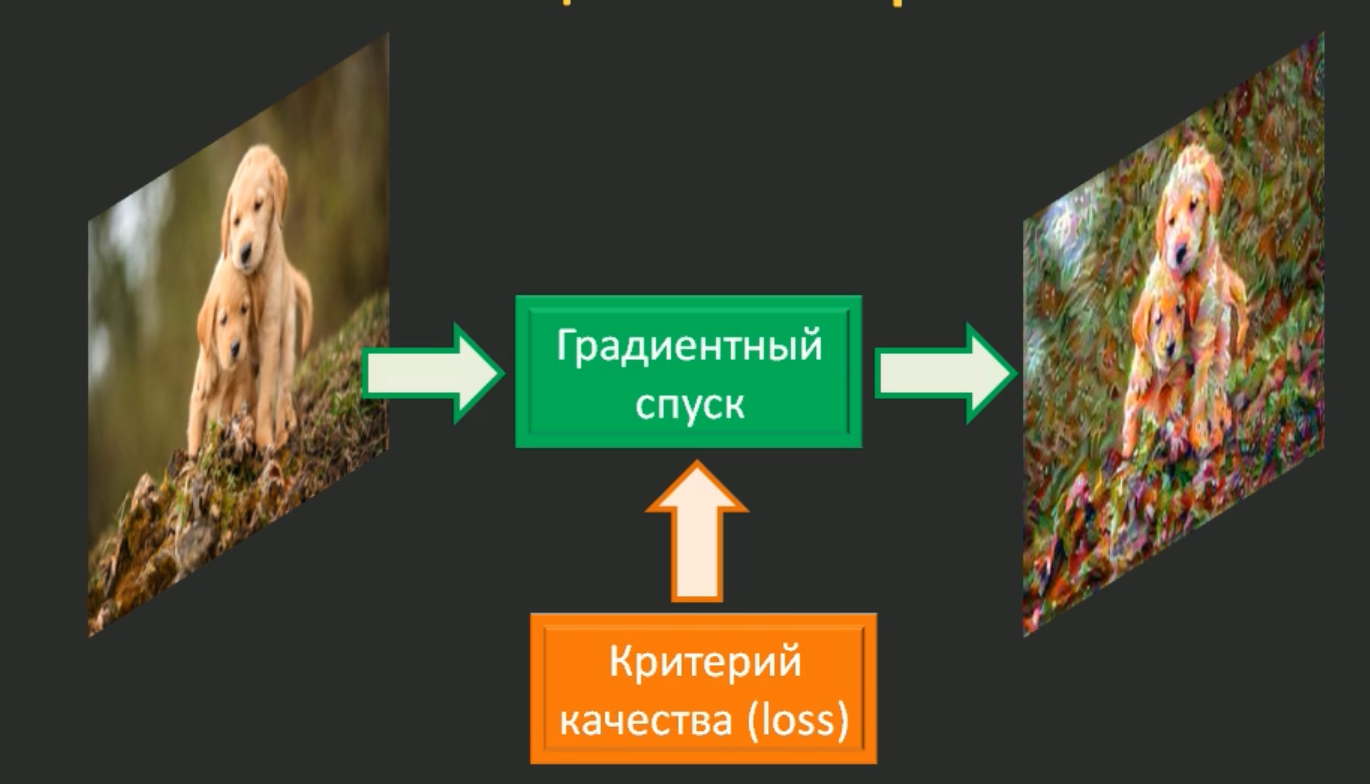

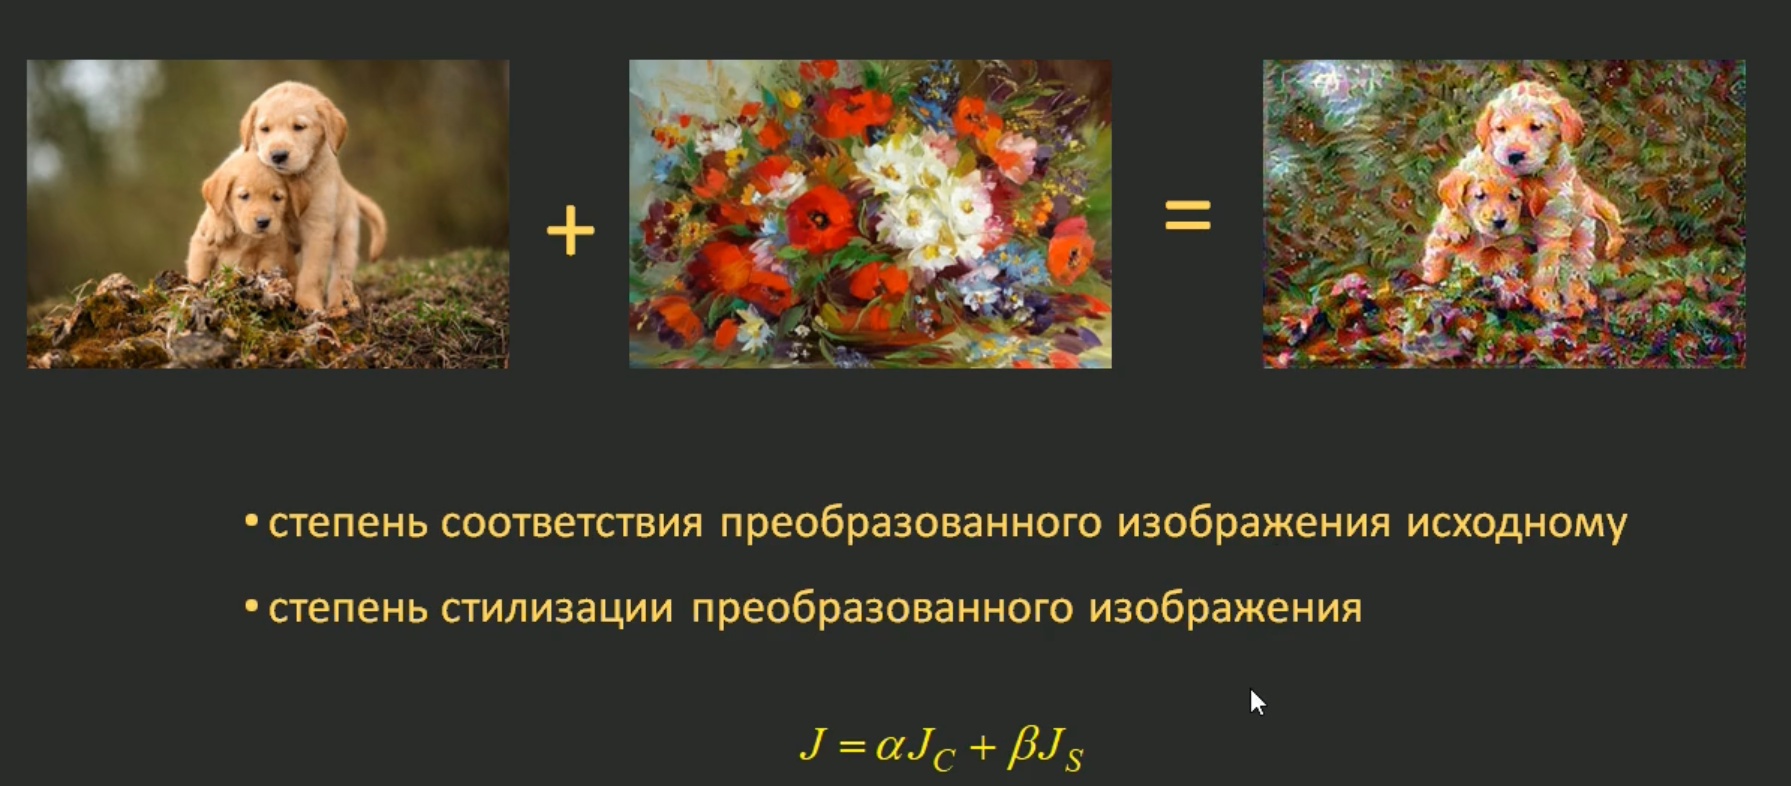

### `Вычисление потерь по контенту (степень соответствия преобразованного изображения исходному)`

1) через нейронную сеть прогоняется ИЗНАЧАЛЬНОЕ изображение и берутся карты признаков с последнего сверточного слоя
2) через нейронную сеть прогоняется СТИЛИЗОВАННОЕ изображение и берутся карты признаков с последнего сверточного слоя
3) вычисляется средний квадрат рассогласования пикселей между двумя полученными наборами карт признаков

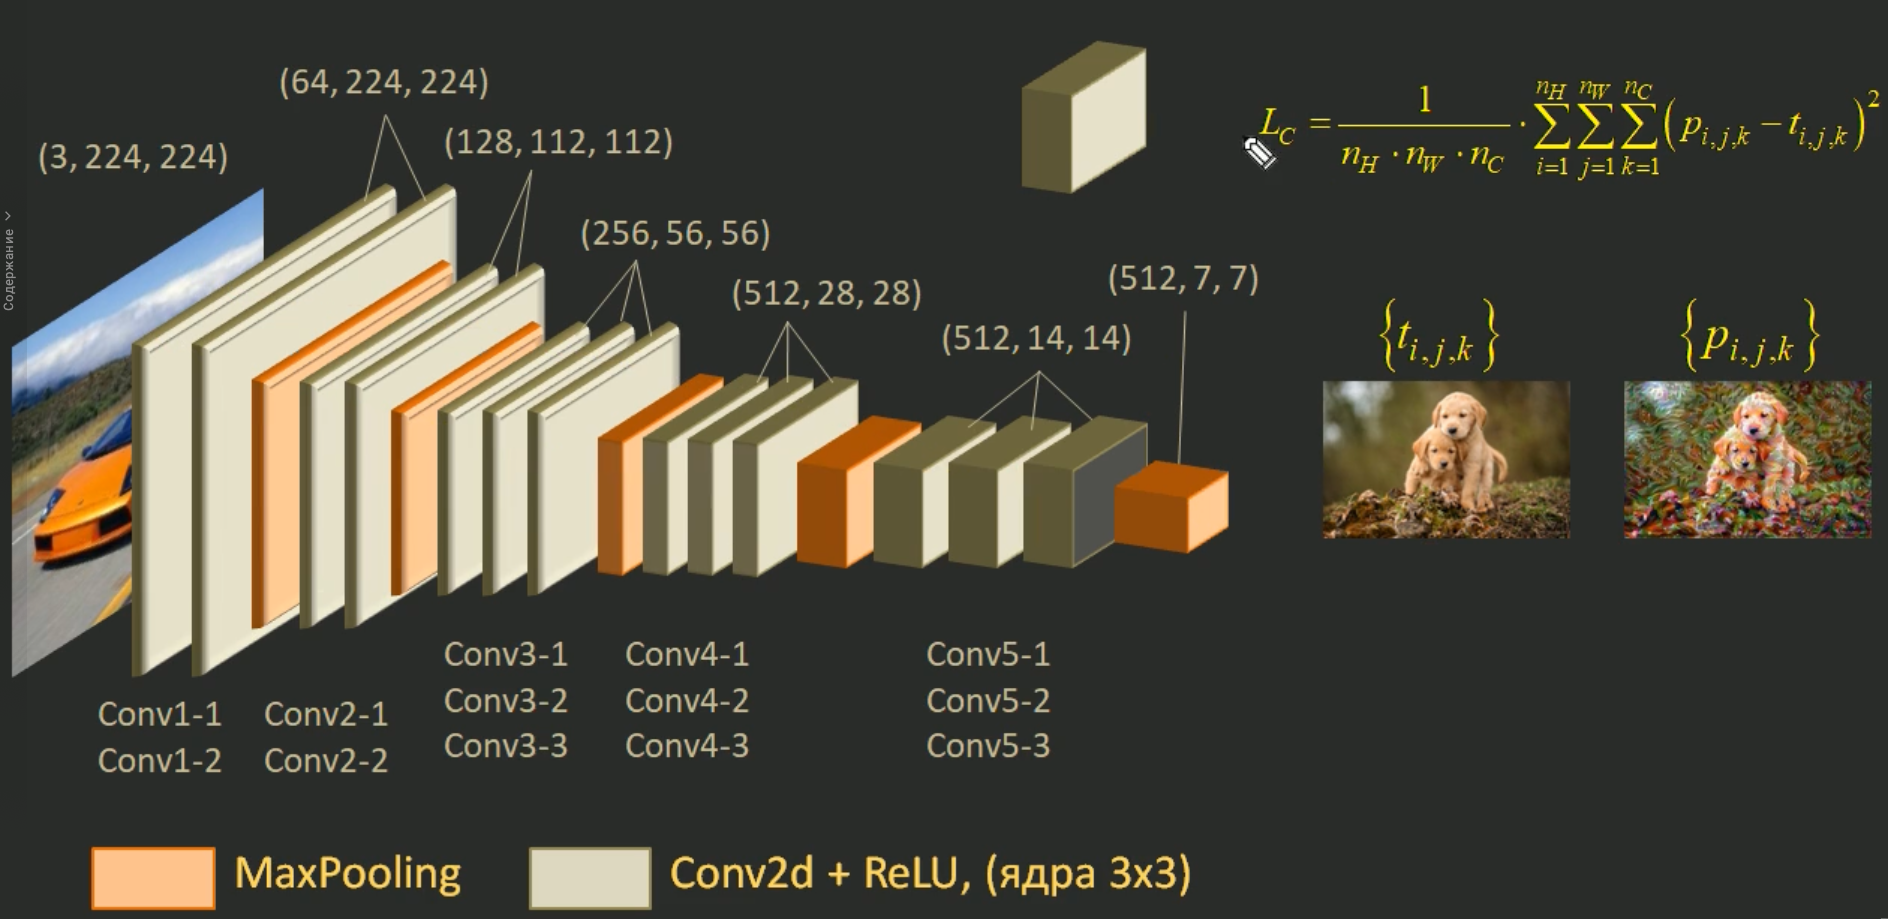

### `Вычисление степени стилизации (степень стилизации преобразованного изображения)`
1) Выбираются n сверточных слоев и с них берутся карты признаков
2) Картиы признаков вытягиваются в матрицу, где по OY цветовые каналы, а по OX вытянутые в вектор изображения в каждом канале
3) Полученные такими преобразованиями матрицы умножатся на себя транспонированных и получается матрица Грамма (автоковариационная матрица), которая описывает линейную степень схожести карт признаков для соответствующего сверточного слоя
4) Такая процедура проводится сначала для изображения, с которого нужно взять стиль, затем для генерируемого изображения
5) Считается мера рассогласования между полученным изображением и изначальным для каждой матрицы Грамма
6) Полученные значения суммируются с некоторыми коэффициентами и получается общая ошибка стилизации

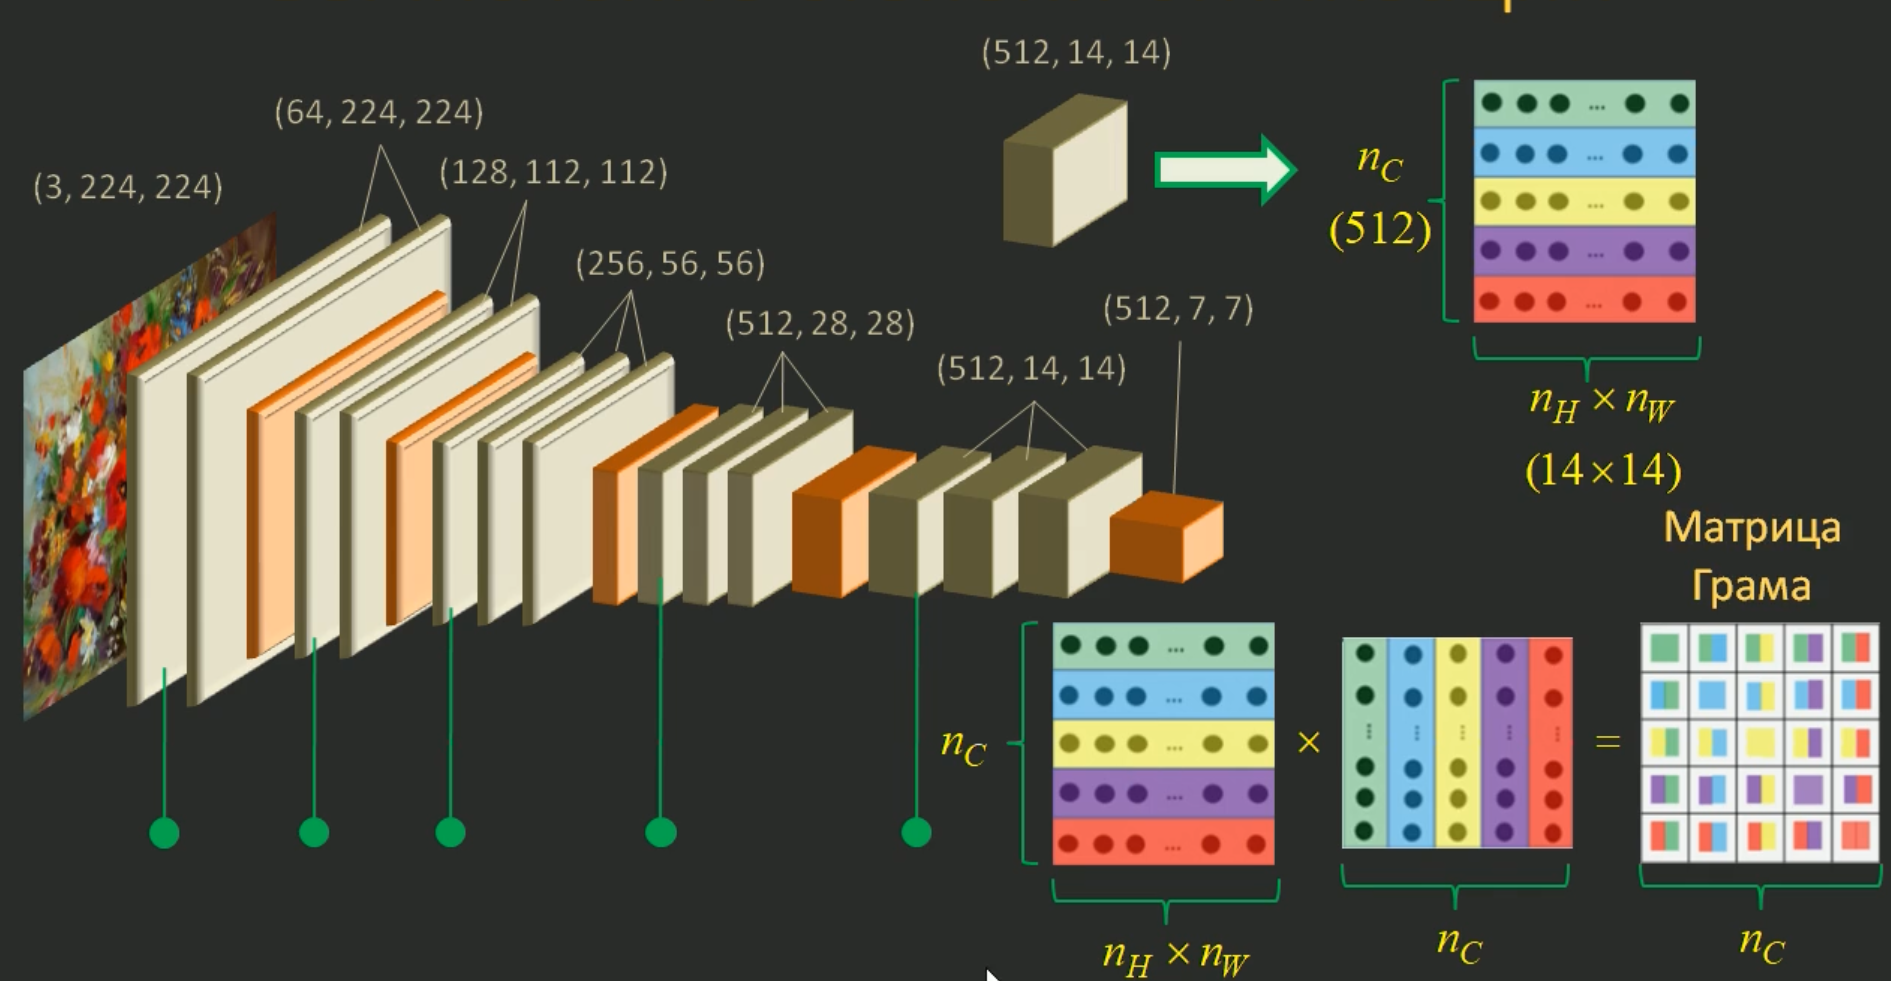

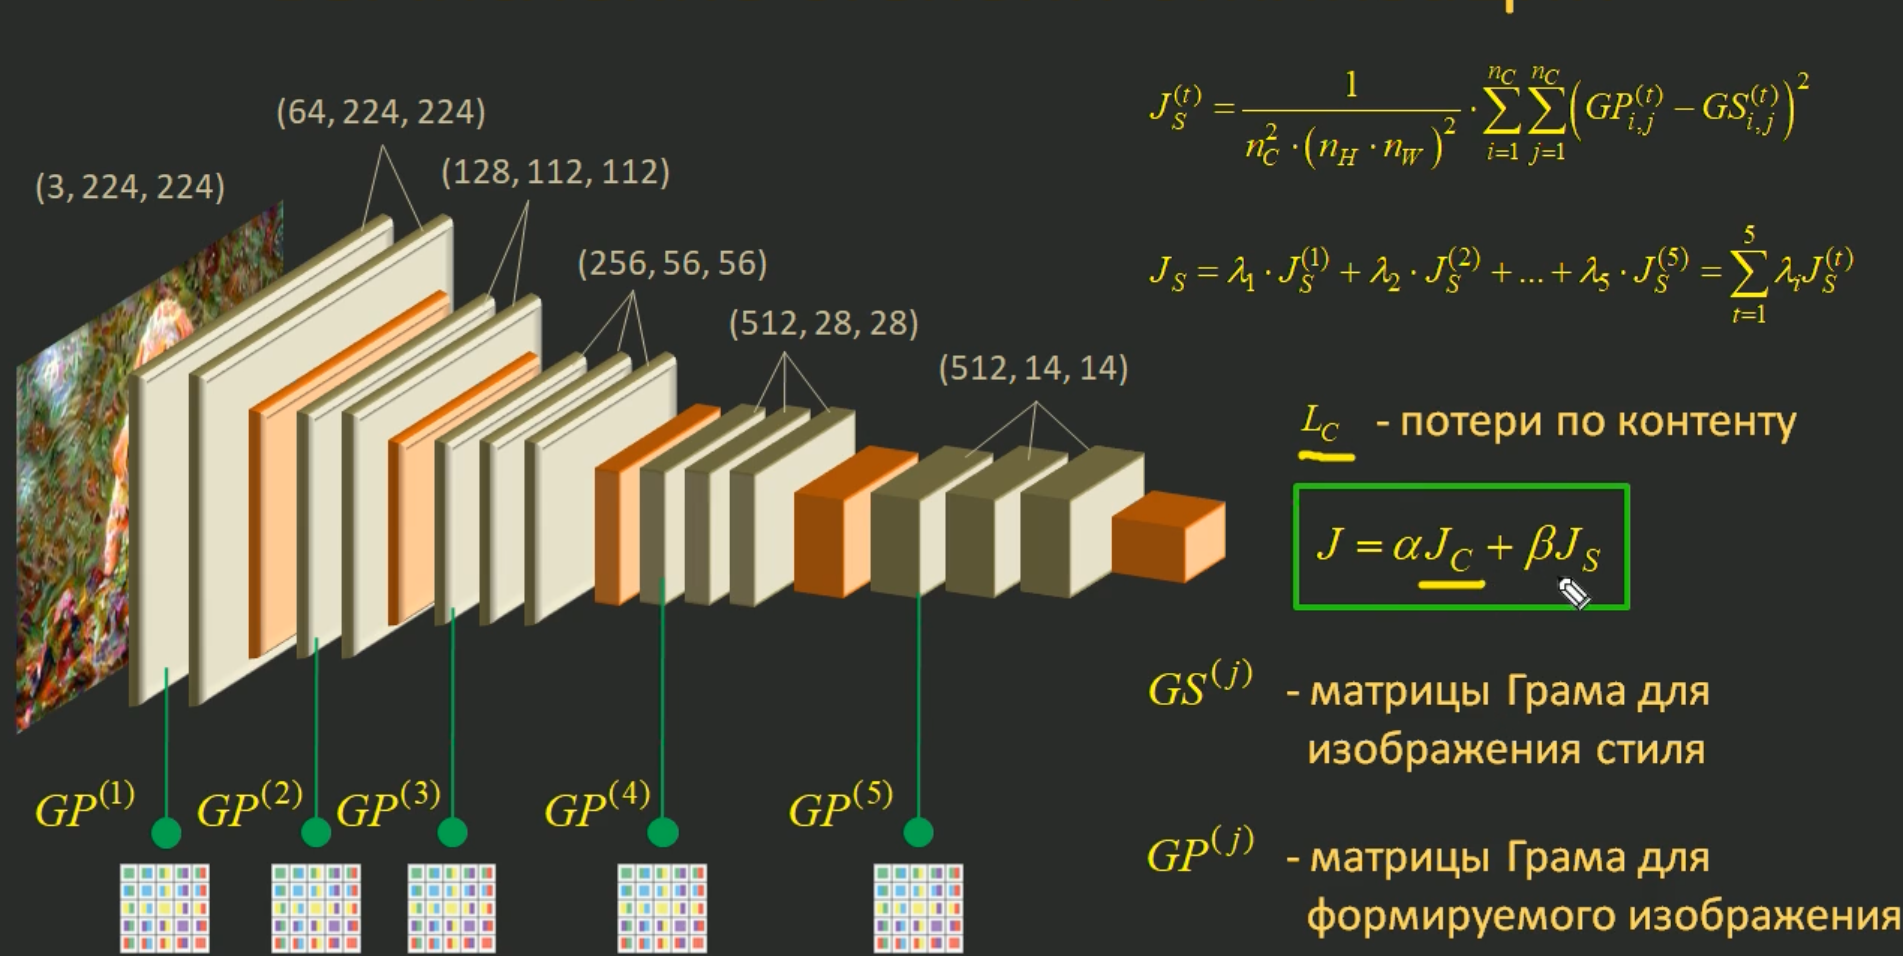

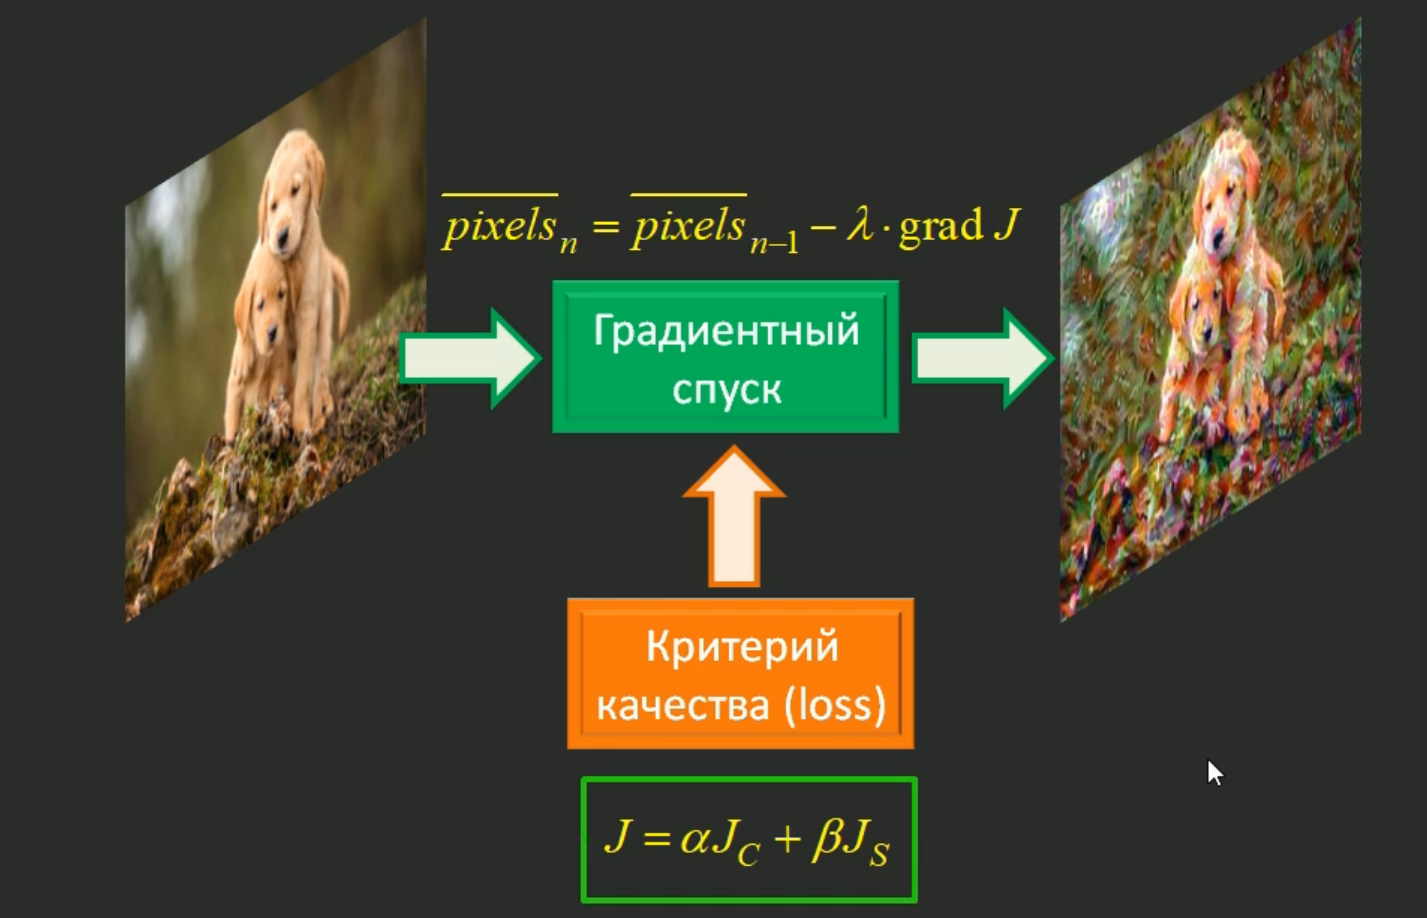

## Написание NST нейросети

In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.v2 as tfs
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [74]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

In [88]:
folder_name = "egor"

In [89]:
class StyleModel(nn.Module):
    def __init__(self):
        super().__init__()
        model_all = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.model = model_all.features
        self.model.requires_grad_(False)
        self.requires_grad_(False)
        self.model.eval()
        self.idx_out = [0, 5, 10, 19, 28, 34]
        self.num_style_layers = len(self.idx_out) - 1

    def forward(self, x):
        result = []

        for idx, layer in enumerate(self.model):
            x = layer(x)

            if idx in self.idx_out:
                result.append(x.squeeze(0))
        
        return result

In [90]:
def get_content_loss(cur_img, base_img):
    return torch.mean(torch.square(cur_img - base_img))

In [91]:
def gram_matrix(features):
    temp = features.view(features.shape[0], -1)
    gram = temp @ temp.T / temp.shape[1]
    return gram

In [92]:
def get_style_loss(cur_style_tensors, base_style_grams):
    style_loss = 0
    style_weights = [1.0, 0.8, 0.5, 0.3, 0.1]
    i = 0

    for cur_tensor, base_gram in zip(cur_style_tensors, base_style_grams):
        cur_gram = gram_matrix(cur_tensor)
        style_loss += style_weights[i] * torch.mean(torch.square(cur_gram - base_gram))
        i += 1

    return style_loss

In [93]:
img = Image.open(f"data/images_nst/{folder_name}/img.jpg")
img_style = Image.open(f"data/images_nst/{folder_name}/img_style.jpg")

transforms = tfs.Compose([tfs.ToImage(), tfs.Resize((224, 224)), tfs.ToDtype(torch.float32, scale=True)])
img = transforms(img).unsqueeze(0)
img_style = transforms(img_style).unsqueeze(0)

img_create = img.clone()
img_create.requires_grad_(True);

In [94]:
model = StyleModel()

outputs_img = model(img)
outputs_img_style = model(img_style)

In [97]:
outputs_img_style_grams = [gram_matrix(x) for x in outputs_img_style[:model.num_style_layers]]
content_weight = 1
style_weight = 1000
best_loss = -1
epochs = 100

In [98]:
optimizer = optim.Adam(params=[img_create], lr=0.01)
best_img = img_create.clone()

In [99]:
for _e in range(epochs):
    cur_tensors = model(img_create)

    content_loss = get_content_loss(cur_tensors[-1], outputs_img[-1])
    style_loss = get_style_loss(cur_tensors[:model.num_style_layers], outputs_img_style_grams)
    loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    img_create.data.clamp_(0, 1) # все значения меньше 0 становятся 0, все значения больше 1 становятся 1

    if loss < best_loss or best_loss < 0:
        best_loss = loss
        best_img = img_create.clone()

    if _e % 9 == 0:
        print(f"Epoch: {_e + 1}, loss: {loss.item(): .4f}")

Epoch: 1, loss:  1159.6454
Epoch: 10, loss:  187.0106
Epoch: 19, loss:  106.5133
Epoch: 28, loss:  76.2778
Epoch: 37, loss:  60.4608
Epoch: 46, loss:  50.6548
Epoch: 55, loss:  44.2127
Epoch: 64, loss:  39.7645
Epoch: 73, loss:  36.5040
Epoch: 82, loss:  33.9327
Epoch: 91, loss:  31.8110
Epoch: 100, loss:  30.0857


In [100]:
x = best_img.detach().squeeze()
low, hi = torch.amin(x), torch.amax(x)
x = (x - low) / (hi - low) * 255.0
x = x.permute(1, 2, 0)
x = x.numpy()
x = np.clip(x, 0, 255).astype('uint8')

In [101]:
image = Image.fromarray(x, 'RGB')
image.save(f"data/images_nst/{folder_name}/result.jpg")

tensor(30.0857, grad_fn=<AddBackward0>)


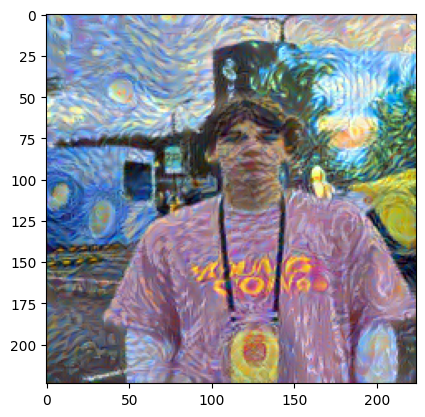

In [102]:
print(best_loss)
plt.imshow(x)
plt.show()